In [1]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
from scipy.integrate import solve_ivp

In [ ]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dualscale import PEMFC
from model.coefficients import *
from modules.signals import generate_step_load
from config.initialize import *
from config.settings import *

In [3]:
# --- Global parameters ---
tstart     = 0.0      # start of each period                    [s]
tend       = 6.0    # end of each period                      [s]
i_low      = 0.002e4      # baseline current density                [A/m^2]
i_high     = 1.2e4    # plateau current density                 [A/m^2]
tau_switch = 1.0     # time (within a period) the ramp BEGINS  [s]
t_switch   = 3.0      # effective ramp duration                 [s]

step_load = generate_step_load(tstart, tend, i_low, i_high, tau_switch, t_switch)

In [4]:
operating_inputs["current_density"] = step_load
model = PEMFC(param=parameters, operating_inputs=operating_inputs,
                           variable_names=solver_variable_names, flux_names=solver_flux_names)
solution_init = init_x(operating_inputs, parameters)
sol = solve_ivp(fun = model.dxdt, y0=solution_init, t_span=(0, 200), method='BDF', max_step=0.1)
model._recovery(sol)

d:\PEMFC\MFC2024\model\inst_values.py:262: RuntimeWarning: invalid value encountered in scalar power
  ans1 = (mliquid * Lgc * nu_l(Tfc)/ (Hgc * rho_H2O(Tfc) * nu_g)) ** (1/3)
c:\ProgramData\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:345: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
c:\ProgramData\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:367: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


In [5]:
states_simlog = model.variables
fluxes_simlog = model.fluxes
echem_traj_simlog = model.echem_traj

In [6]:
t_start_plot = 50
i_start_plot = np.argmax(np.array(model.variables["t"]) > t_start_plot)
t_end_plot = 100
i_end_plot = np.argmin(np.array(model.variables["t"]) < t_end_plot)

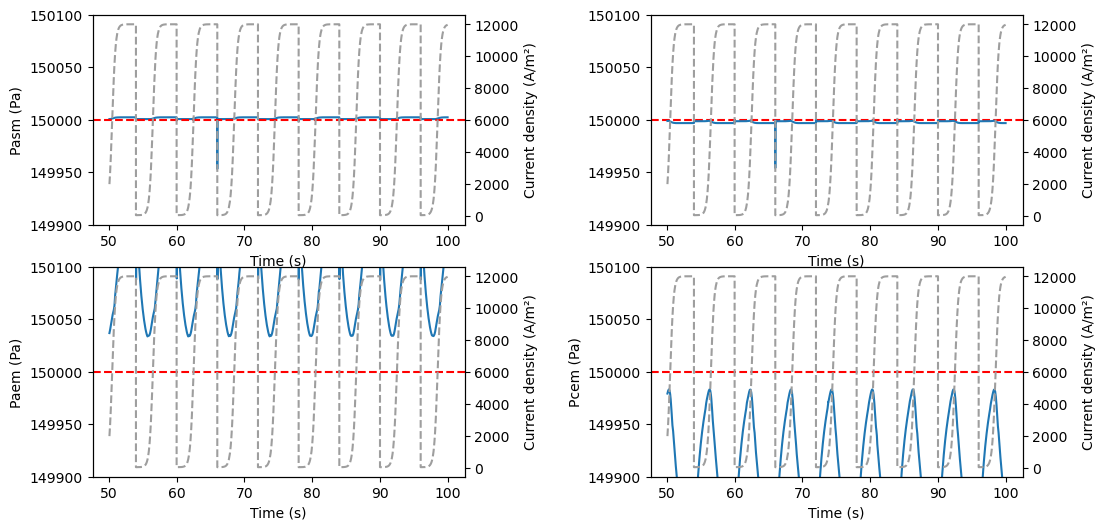

In [31]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.5)
ax[0,0].plot(model.variables["t"][i_start_plot:i_end_plot], model.variables["Pasm"][i_start_plot:i_end_plot], label="Pasm")
ax[1,0].plot(model.variables["t"][i_start_plot:i_end_plot], model.variables["Pcsm"][i_start_plot:i_end_plot], label="Pcsm")
ax[0,0].set_ylabel("Pasm (Pa)")
ax[1,0].set_ylabel("Pcsm (Pa)")
ax[0,0].axhline(y=model.operating_inputs["Pa_des"], color='r', linestyle='--', label="Pa setpoint")
ax[0,1].axhline(y=model.operating_inputs["Pc_des"], color='r', linestyle='--', label="Pc setpoint")
ax[0,1].plot(model.variables["t"][i_start_plot:i_end_plot], model.variables["Paem"][i_start_plot:i_end_plot], label="Paem")
ax[1,1].plot(model.variables["t"][i_start_plot:i_end_plot], model.variables["Pcem"][i_start_plot:i_end_plot], label="Pcem")
ax[1,0].set_ylabel("Paem (Pa)")
ax[1,1].set_ylabel("Pcem (Pa)")
ax[1,0].axhline(y=model.operating_inputs["Pa_des"], color='r', linestyle='--', label="Pa setpoint")
ax[1,1].axhline(y=model.operating_inputs["Pc_des"], color='r', linestyle='--', label="Pc setpoint")

for ax_i in ax.flatten():
    ax_i.set_ylim(model.operating_inputs["Pa_des"] - 100, model.operating_inputs["Pa_des"] + 100)
    ax_load = ax_i.twinx()
    ax_load.plot(model.variables["t"][i_start_plot:i_end_plot], model.echem_traj["i_fc"][i_start_plot:i_end_plot], color = "#9E9E9E", linestyle='--', label="i_fc")
    ax_load.set_ylabel("Current density (A/m²)")
    ax_i.set_xlabel("Time (s)")

Kd two to three orders below Kp until you see the response.

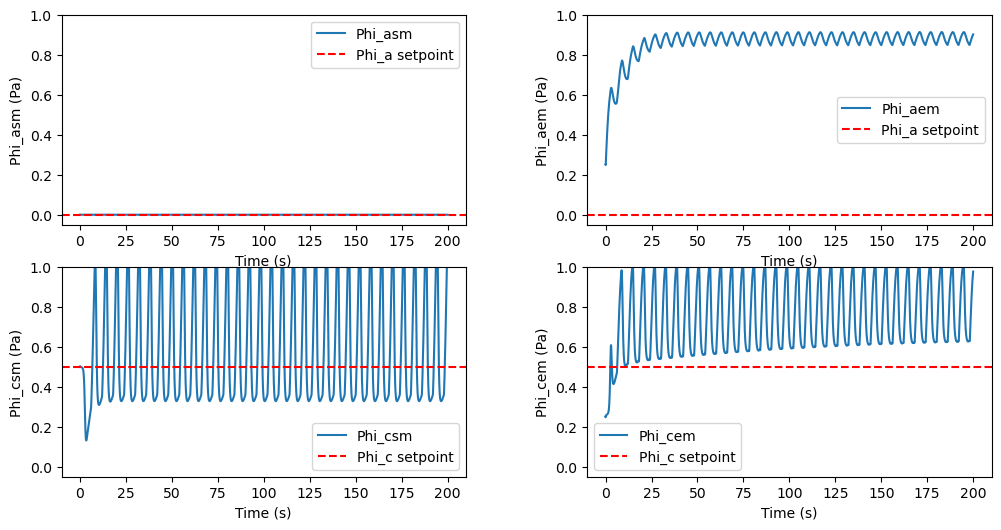

In [8]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.3)
ax[0,0].plot(model.variables["t"], model.variables["Phi_asm"], label="Phi_asm")
ax[0,1].plot(model.variables["t"], model.variables["Phi_aem"], label="Phi_aem")
ax[1,1].plot(model.variables["t"], model.variables["Phi_cem"], label="Phi_cem")
ax[1,0].plot(model.variables["t"], model.variables["Phi_csm"], label="Phi_csm")
ax[0,0].set_ylabel("Phi_asm (Pa)")
ax[0,1].set_ylabel("Phi_aem (Pa)")
ax[1,0].set_ylabel("Phi_csm (Pa)")
ax[1,1].set_ylabel("Phi_cem (Pa)")
ax[0,0].axhline(y=model.operating_inputs["Phi_a_des"], color='r', linestyle='--', label="Phi_a setpoint")
ax[0,1].axhline(y=model.operating_inputs["Phi_a_des"], color='r', linestyle='--', label="Phi_a setpoint")
ax[1,0].axhline(y=model.operating_inputs["Phi_c_des"], color='r', linestyle='--', label="Phi_c setpoint")
ax[1,1].axhline(y=model.operating_inputs["Phi_c_des"], color='r', linestyle='--', label="Phi_c setpoint")
for axi in ax.flatten():
    axi.set_ylim(-0.05, 1)
    axi.legend()
    axi.set_xlabel("Time (s)")

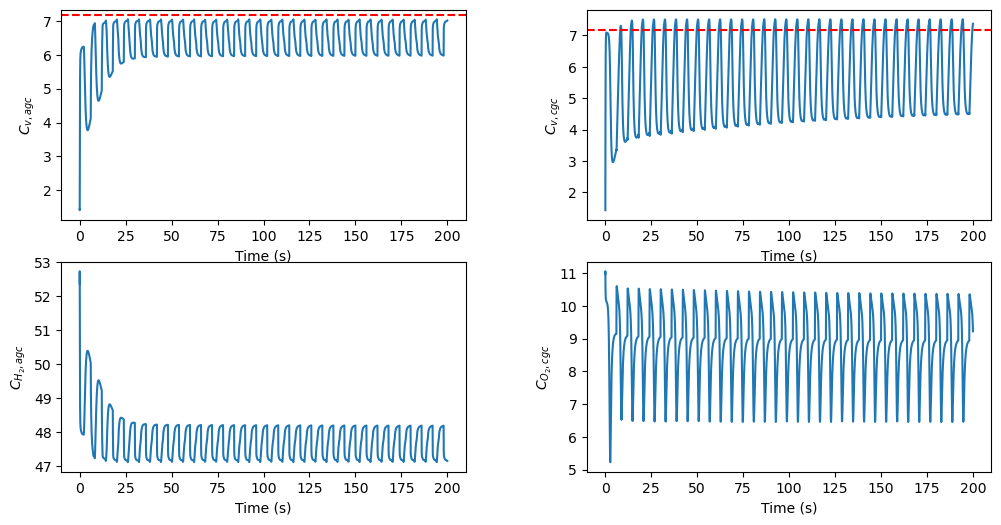

In [9]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.3)
ax[0,0].plot(model.variables["t"], model.variables["C_v_agc"])
ax[0,0].axhline(y=C_v_sat(model.operating_inputs["Tfc"]), color='r', linestyle='--', label="Phi_a setpoint")
ax[0,1].plot(model.variables["t"], model.variables["C_v_cgc"])
ax[0,1].axhline(y=C_v_sat(model.operating_inputs["Tfc"]), color='r', linestyle='--', label="Phi_a setpoint")
ax[1,0].plot(model.variables["t"], model.variables["C_H2_agc"])
ax[1,1].plot(model.variables["t"], model.variables["C_O2_cgc"])
ax[0,0].set_ylabel(r"$C_{v,agc}$")
ax[0,1].set_ylabel(r"$C_{v,cgc}$")
ax[1,0].set_ylabel(r"$C_{H_2,agc}$")
ax[1,1].set_ylabel(r"$C_{O_2,cgc}$")
for axi in ax.flatten():
    axi.set_xlabel("Time (s)")

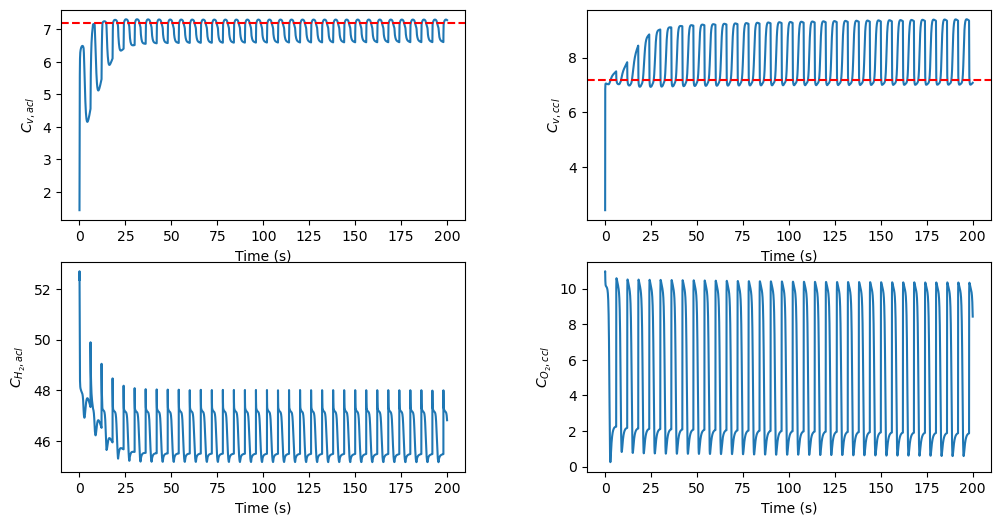

In [13]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.3)
ax[0,0].plot(model.variables["t"], model.variables["C_v_acl"])
ax[0,0].axhline(y=C_v_sat(model.operating_inputs["Tfc"]), color='r', linestyle='--', label="Phi_a setpoint")
ax[0,1].plot(model.variables["t"], model.variables["C_v_ccl"])
ax[0,1].axhline(y=C_v_sat(model.operating_inputs["Tfc"]), color='r', linestyle='--', label="Phi_a setpoint")
ax[1,0].plot(model.variables["t"], model.variables["C_H2_acl"])
ax[1,1].plot(model.variables["t"], model.variables["C_O2_ccl"])
ax[0,0].set_ylabel(r"$C_{v,acl}$")
ax[0,1].set_ylabel(r"$C_{v,ccl}$")
ax[1,0].set_ylabel(r"$C_{H_2,acl}$")
ax[1,1].set_ylabel(r"$C_{O_2,ccl}$")
for axi in ax.flatten():
    axi.set_xlabel("Time (s)")

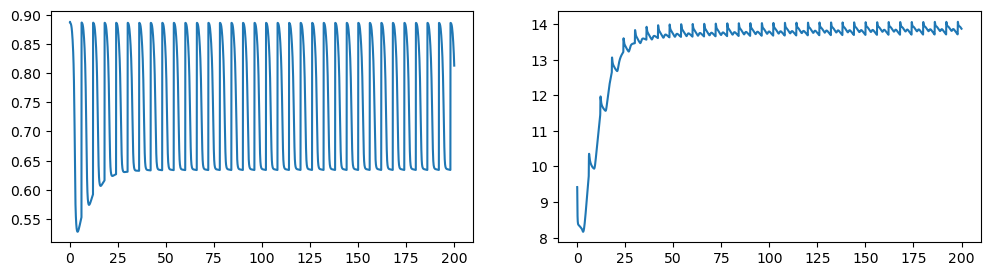

In [30]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 3))
ax[0].plot(model.variables["t"], (np.array(model.echem_traj["Ucell"])-0.3))
ax[1].plot(model.variables["t"], model.variables["lambda_mem_5"])

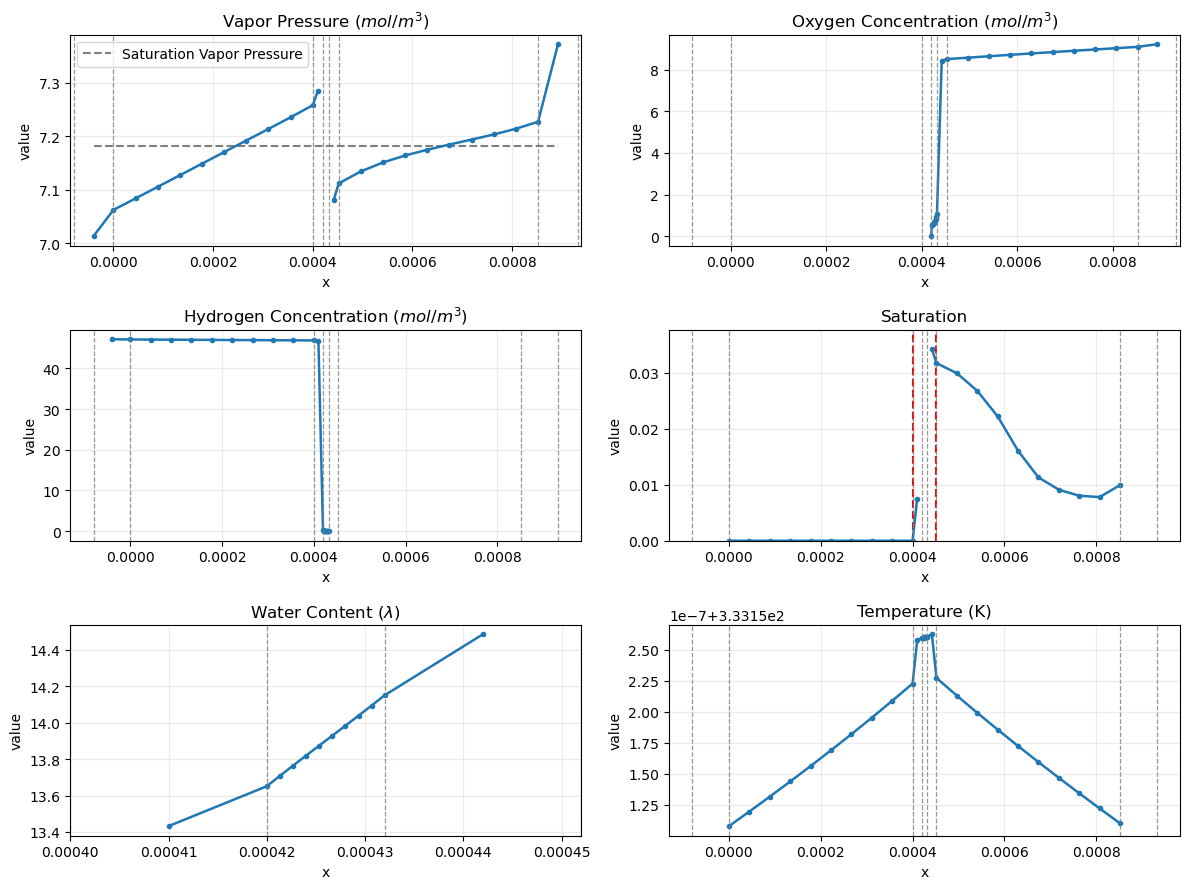

In [10]:
from modules.display import display
display(sol, model)